# Multi-shot inning demo

Drive `Billiards4BallInningEnv` with the geometric-aim baseline policy until the cue ball misses, fouls, or the per-inning shot cap fires. The full inning is rendered inline as a single self-contained HTML viewer.

Inning ends on:
- **terminated** — score = 0 (miss) or `fouled=True`
- **truncated** — `max_shots` reached


In [1]:
import sys
from pathlib import Path

import numpy as np
from IPython.display import HTML, display

ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

In [2]:
from billiards.inning_env import Billiards4BallInningEnv
from billiards.render.replay import render_inning_html
from policies.geometric_aim import GeometricAimPolicy

In [3]:
env = Billiards4BallInningEnv(max_shots=20)
obs, info = env.reset(seed=0)
policy = GeometricAimPolicy(power=0.6, avoid_opp=True)
print('obs shape:', obs.shape, '| spec width:', info['spec']['width'])

obs shape: (28,) | spec width: 2.54


In [4]:
rewards: list[float] = []
while True:
    action = policy.act(obs)
    obs, reward, terminated, truncated, info = env.step(action)
    rewards.append(float(reward))
    if terminated or truncated:
        break

print(f"inning ended | shots={env.shot_index} cumulative_score={env.cumulative_score} terminated={terminated} truncated={truncated}")

inning ended | shots=1 cumulative_score=0 terminated=True truncated=False



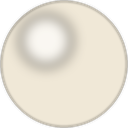
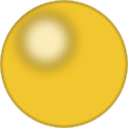
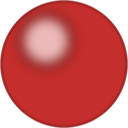
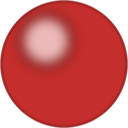

In [5]:
html = render_inning_html(env.shot_trajectories, spec=env._spec)
display(HTML(html.data) if hasattr(html, 'data') else html)

In [6]:
log = env.inning_log
header = f"{'shot':>4} {'score':>5} {'foul':>5} {'cushions':>9} {'duration':>9}"
print(header)
print('-' * len(header))
for rec in log:
    print(f"{rec['shot_index']:>4} {rec['score']:>5} {str(rec['fouled']):>5} {rec['cushion_hits']:>9} {rec['duration']:>9.3f}")

shot score  foul  cushions  duration
------------------------------------
   1     0 False         1     4.700


In [7]:
total_shots = len(log)
total_score = sum(r['score'] for r in log)
total_duration = sum(r['duration'] for r in log)
total_cushions = sum(r['cushion_hits'] for r in log)
print(f"TOTAL shots={total_shots} score={total_score} duration={total_duration:.3f}s cushions={total_cushions}")

TOTAL shots=1 score=0 duration=4.700s cushions=1
